In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
resume_df = pd.read_csv("Resume.csv")
jd_df = pd.read_csv("postings.csv")

print("Resume shape:", resume_df.shape)
print("JD shape:", jd_df.shape)

resume_df.head()

Resume shape: (2484, 4)
JD shape: (123849, 31)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
print("Resume missing values:")
print(resume_df.isnull().sum())

print("\nJD missing values:")
print(jd_df.isnull().sum())

Resume missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

JD missing values:
job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain           

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = " ".join(text.split())
    return text

In [5]:
resume_df["clean_resume"] = resume_df["Resume_str"].apply(clean_text)
jd_df["clean_jd"] = jd_df["description"].apply(clean_text)

print("Cleaning complete.")

Cleaning complete.


In [6]:
print("Original Resume:")
print(resume_df["Resume_str"].iloc[0][:300])

print("\nCleaned Resume:")
print(resume_df["clean_resume"].iloc[0][:300])

Original Resume:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

Cleaned Resume:
hr administrator marketing associate hr administrator summary dedicated customer service manager with 15 years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service h


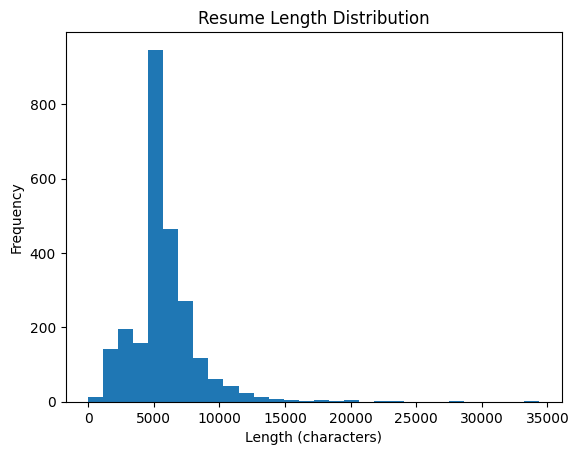

In [7]:
resume_df["resume_length"] = resume_df["clean_resume"].apply(len)

plt.figure()
plt.hist(resume_df["resume_length"], bins=30)
plt.title("Resume Length Distribution")
plt.xlabel("Length (characters)")
plt.ylabel("Frequency")
plt.show()

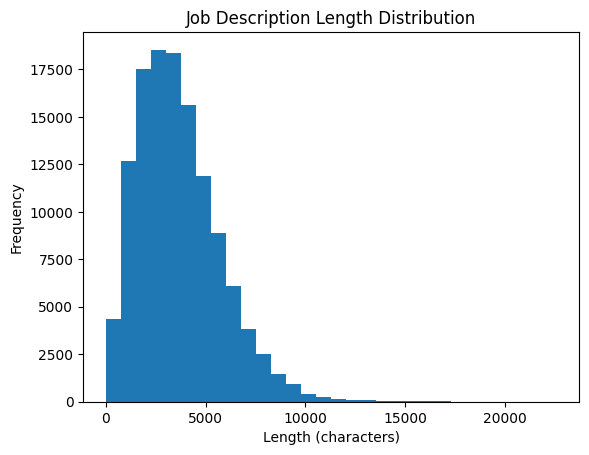

In [8]:
jd_df["jd_length"] = jd_df["clean_jd"].apply(len)

plt.figure()
plt.hist(jd_df["jd_length"], bins=30)
plt.title("Job Description Length Distribution")
plt.xlabel("Length (characters)")
plt.ylabel("Frequency")
plt.show()

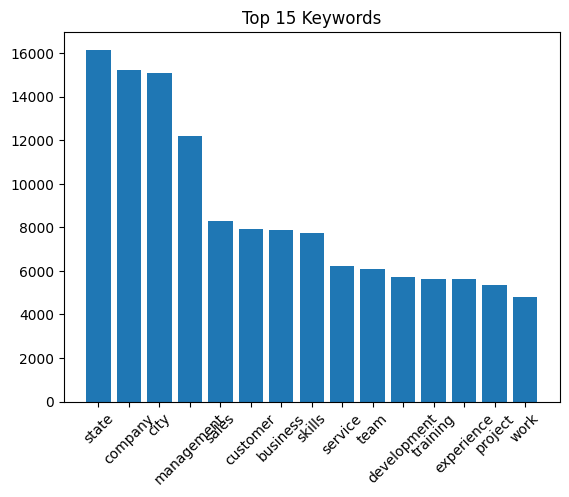

[('state', 16159), ('company', 15212), ('city', 15077), ('management', 12174), ('sales', 8275), ('customer', 7927), ('business', 7866), ('skills', 7729), ('service', 6223), ('team', 6073), ('development', 5731), ('training', 5637), ('experience', 5632), ('project', 5362), ('work', 4817)]


In [9]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

all_words = " ".join(resume_df["clean_resume"]).split()

filtered_words = [
    word for word in all_words
    if word not in ENGLISH_STOP_WORDS and len(word) > 3
]

word_counts = Counter(filtered_words)
top_15 = word_counts.most_common(15)

words = [w[0] for w in top_15]
counts = [w[1] for w in top_15]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Keywords")
plt.show()

print(top_15)

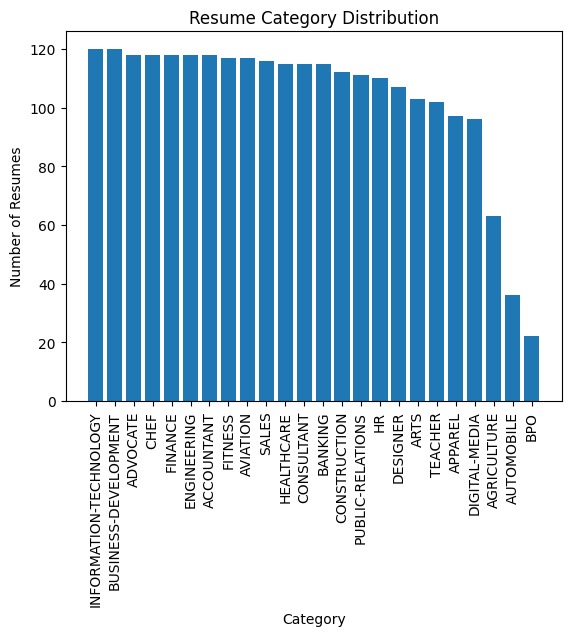

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [10]:
category_counts = resume_df["Category"].value_counts()

plt.figure()
plt.bar(category_counts.index, category_counts.values)
plt.xticks(rotation=90)
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.show()

print(category_counts)

In [11]:
selected_job = jd_df["clean_jd"].iloc[0]

In [12]:
corpus = list(resume_df["clean_resume"])
corpus.append(selected_job)

In [13]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(corpus)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (2485, 40167)


In [14]:
job_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]

In [15]:
similarity_scores = cosine_similarity(resume_vectors, job_vector)

resume_df["similarity_score"] = similarity_scores.flatten()
resume_df.head()

,ID,Resume_str,Resume_html,Category,clean_resume,resume_length,similarity_score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,4859,0.102106
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,5042,0.166691
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary over 20 years experience i...,7168,0.079793
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven and dyn...,2597,0.038301
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,8619,0.053725


In [16]:
ranked_df = resume_df.sort_values(by="similarity_score", ascending=False)

top_10 = ranked_df.head(10)

top_10[["ID", "Category", "similarity_score"]]

,ID,Category,similarity_score
1318,22706174,DIGITAL-MEDIA,0.223019
201,15425154,DESIGNER,0.218367
159,54201930,DESIGNER,0.200735
151,26046064,DESIGNER,0.192393
1314,23810469,DIGITAL-MEDIA,0.190938
178,18460045,DESIGNER,0.181617
1224,26167298,CONSULTANT,0.178116
1687,19714635,APPAREL,0.174134
2086,31220062,PUBLIC-RELATIONS,0.171585
1,22323967,HR,0.166691


In [17]:
top_10.to_csv("results_sample.csv", index=False)

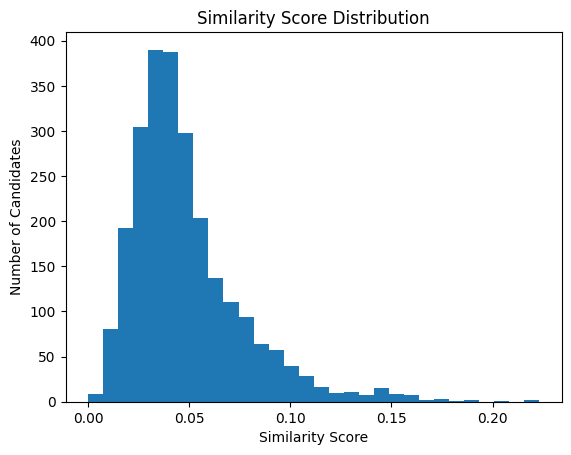

In [18]:
plt.figure()

plt.hist(resume_df["similarity_score"], bins=30)

plt.title("Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Number of Candidates")

plt.show()

In [26]:
resume_df.to_csv('candidates_cleaned.csv', index=False)
jd_df.to_csv('jobs_cleaned.csv', index=False)
ranked_df.to_csv('ranked_cleaned.csv', index=False)

In [27]:
import random

first_names = [
    "James", "Sarah", "David", "Priya", "Michael", "Emily", "Daniel", "Jessica",
    "Ryan", "Aisha", "Chris", "Natalie", "Kevin", "Laura", "Omar", "Sophia",
    "Ethan", "Maya", "Lucas", "Zara", "Brandon", "Isabella", "Nathan", "Fatima"
]

last_names = [
    "Anderson", "Mitchell", "Chen", "Patel", "Brown", "Rodriguez", "Kim", "Taylor",
    "O'Brien", "Johnson", "Walker", "Singh", "Nguyen", "Martinez", "Hassan", "Lee",
    "Williams", "Sharma", "Thompson", "Ahmed", "Scott", "Clark", "Wright", "Ali"
]

random.seed(42)  # keeps names consistent every time you run it
resume_df['name'] = [
    f"{random.choice(first_names)} {random.choice(last_names)}"
    for _ in range(len(resume_df))
]

resume_df.to_csv('candidates_cleaned.csv', index=False)
print("Done! Sample names:", resume_df['name'].head().tolist())

Done! Sample names: ['Brandon Patel', 'James Ali', 'Ryan Taylor', 'Jessica Brown', 'Fatima Patel']
